In [1]:
# Import libraries and functions
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from formulas import generate_transition_matrix, make_prediction, tabulate, define_traffic, set_traffic_simulation

In [2]:
# Adjacency matrix: network connections
adjacency_matrix = np.array([
    [0, 1, 0, 1],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 0, 1, 0]
    ])

# Initial transition matrix: movement probabilities
transition_matrix = np.array([
    [0, 0.5, 0, 0.5],
    [0.5, 0, 0.5, 0],
    [0, 0.5, 0, 0.5],
    [0.5, 0, 0.5, 0]
    ])

In [3]:
# Capacity matrix: max traffic per intersection
capacity_matrix = np.array([700, 800, 700, 600])

traffic_vector, queue, get_entrants = set_traffic_simulation()

In [4]:
# Table for simulation data
table = [[], [], [], [], []]  # [iterations, A, B, C, D]

In [5]:
# Simulation loop: update traffic over 100 iterations
n = 0
while n < 100:
    prediction = make_prediction(transition_matrix=transition_matrix, traffic_vector=traffic_vector, entrants=get_entrants())
    print("prediction:", prediction)
    
    trans_matrix, queue = generate_transition_matrix(transition_matrix=transition_matrix, adjacency_matrix=adjacency_matrix, capacity_matrix=capacity_matrix, org_queue=queue, traffic_vector=traffic_vector, prediction=prediction, rows=4, cols=4)
    print("before TM:", transition_matrix)

    traffic_vector = queue.astype(np.int64)

    transition_matrix = np.array(trans_matrix)
    print("after TM:", transition_matrix)

    print("T_V:", traffic_vector)

    tabulate(n, queue, table=table)
    n += 1

prediction: [ 780.5 1675.   855.5 1178. ]
before TM: [[0.  0.5 0.  0.5]
 [0.5 0.  0.5 0. ]
 [0.  0.5 0.  0.5]
 [0.5 0.  0.5 0. ]]
after TM: [[0.         0.72938123 0.         0.27061877]
 [0.59761441 0.         0.40238559 0.        ]
 [0.         0.72938123 0.         0.27061877]
 [0.59761441 0.         0.40238559 0.        ]]
T_V: [564  64 784 636]
prediction: [ 509.33008763 1427.20589778 1221.66991237  904.79410222]
before TM: [[0.         0.72938123 0.         0.27061877]
 [0.59761441 0.         0.40238559 0.        ]
 [0.         0.72938123 0.         0.27061877]
 [0.59761441 0.         0.40238559 0.        ]]
after TM: [[0.         0.78195489 0.         0.21804511]
 [0.55371094 0.         0.44628906 0.        ]
 [0.         0.78195489 0.         0.21804511]
 [0.55371094 0.         0.44628906 0.        ]]
T_V: [543  25 759 613]
prediction: [1301.26757812 1022.10526316  301.73242187  749.89473684]
before TM: [[0.         0.78195489 0.         0.21804511]
 [0.55371094 0.         0.44

In [6]:
# Create dataframe from table
data_frame = pd.DataFrame(table, index=["Iteration", "Traffic at A", "Traffic at B", "Traffic at C", "Traffic at D"])
data_frame

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
Iteration,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,90.0,91.0,92.0,93.0,94.0,95.0,96.0,97.0,98.0,99.0
Traffic at A,564.0,543.0,511.0,491.0,462.0,445.0,430.0,404.0,386.0,360.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Traffic at B,64.0,25.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Traffic at C,784.0,759.0,743.0,726.0,698.0,674.0,651.0,630.0,607.0,584.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Traffic at D,636.0,613.0,589.0,564.0,546.0,519.0,498.0,469.0,445.0,428.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


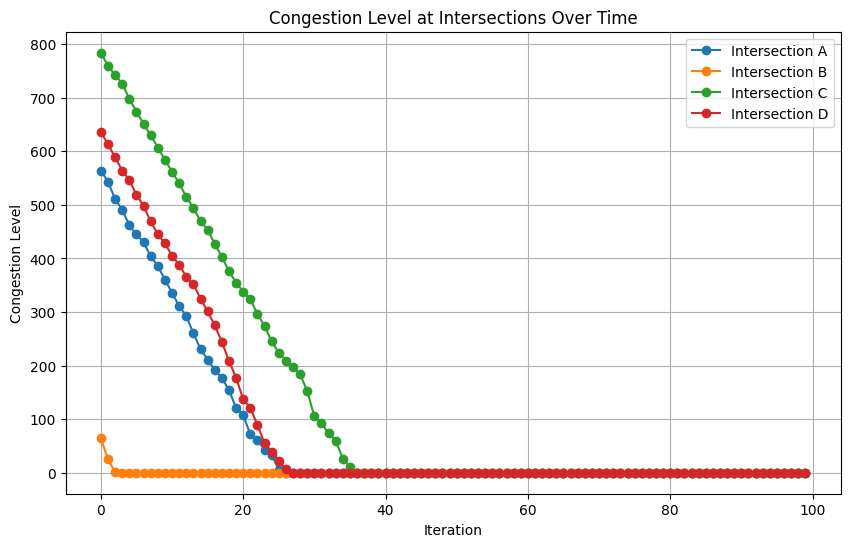

In [7]:
# Plot congestion levels over time
plt.figure(figsize=(10, 6))
plt.plot(data_frame.iloc[0], data_frame.iloc[1], marker='o')
plt.plot(data_frame.iloc[0], data_frame.iloc[2], marker='o')
plt.plot(data_frame.iloc[0], data_frame.iloc[3], marker='o')
plt.plot(data_frame.iloc[0], data_frame.iloc[4], marker='o')
plt.title('Congestion Level at Intersections Over Time')
plt.xlabel('Iteration')
plt.ylabel('Congestion Level')
plt.legend(['Intersection A', 'Intersection B', 'Intersection C', 'Intersection D'])
plt.grid()
plt.show()